# CCM pt 2 — Reevaluation

**Analysis pipeline:**
1. **SHREC** — extract the shared latent manifold of *anchovy × sardine* (ψ₁, ψ₂)
2. **SINDy residuals** — compute what the sparse equations could not predict
3. **Step 1** — CCM: ψ₁ *and* ψ₂ vs fish populations
4. **Step 2** — CCM: ψ₁ *and* ψ₂ vs SINDy residuals
5. **Step 3** — Convergence fits for all CCM curves

> **Why anchovy × sardine for SHREC?**  
> SINDy was given *anchovy* and *sardine* (plus SST) and discovered equations that couple
> the two fish populations.  The ψ we feed into CCM must represent the shared dynamical
> structure of *those same two variables* — otherwise we would be importing causal
> information from a different manifold.  Running SHREC on anchovy + sardine gives us
> the latent coordinate that lives inside their joint attractor, which is exactly what
> we want to test against SINDy's residuals.


## — Imports & Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.spatial import cKDTree
from scipy.spatial.distance import cdist
from scipy.linalg import eigh
from scipy.stats import pearsonr
from scipy.optimize import curve_fit, OptimizeWarning
import gzip, struct, warnings

# ── Path ──────────────────────────────────────────────────────────────────────
RDATA_PATH = r'sardine_anchovy_sst.RData'   # <── update if needed

# ── Loaders ───────────────────────────────────────────────────────────────────
def load_via_pyreadr(filepath):
    import pyreadr
    result = pyreadr.read_r(filepath)
    df = result[list(result.keys())[0]]
    df['year'] = pd.to_datetime(df['year'], format='%Y')
    df = df.sort_values('year').set_index('year').interpolate(method='linear')
    years = df.index.year.values
    df_n  = (df - df.mean()) / df.std()
    return (years,
            df_n['anchovy'].values, df_n['sardine'].values,
            df_n['sio_sst'].values, df_n['np_sst'].values)

def load_via_binary(filepath):
    with gzip.open(filepath, 'rb') as fh:
        raw = fh.read()
    N = 78
    years   = np.array([struct.unpack_from('>i', raw,  70 + i*4)[0] for i in range(N)])
    anchovy = np.array([struct.unpack_from('>d', raw, 390 + i*8)[0] for i in range(N)])
    sardine = np.array([struct.unpack_from('>d', raw,1022 + i*8)[0] for i in range(N)])
    sio_sst = np.array([struct.unpack_from('>d', raw,1654 + i*8)[0] for i in range(N)])
    np_sst  = np.array([struct.unpack_from('>d', raw,2286 + i*8)[0] for i in range(N)])
    def z(x): return (x - x.mean()) / x.std()
    return years, z(anchovy), z(sardine), z(sio_sst), z(np_sst)

try:
    years, anchovy, sardine, sio_sst, np_sst = load_via_pyreadr(RDATA_PATH)
    print(f"✅ pyreadr — {len(years)} obs  ({years[0]}–{years[-1]})")
except Exception as e1:
    try:
        years, anchovy, sardine, sio_sst, np_sst = load_via_binary(RDATA_PATH)
        print(f"✅ binary parser — {len(years)} obs  ({years[0]}–{years[-1]})")
    except Exception as e2:
        raise RuntimeError(
            f"Data load failed.\n  pyreadr: {e1}\n  binary: {e2}\n"
            "Put 'sardine_anchovy_sst.RData' in the working directory.")

N = len(years)
print(f"   Variables: anchovy std={anchovy.std():.3f}, sardine std={sardine.std():.3f}")


✅ pyreadr — 78 obs  (1929–2006)
   Variables: anchovy std=0.994, sardine std=0.994


## 1 — Helper Functions

In [2]:
# ── Time-delay embedding ──────────────────────────────────────────────────────
def embed(ts, E, tau=1):
    """Returns (N, E) array; the first (E-1)*tau rows are NaN (no history yet)."""
    N = len(ts)
    out = np.full((N, E), np.nan)
    for i in range(E):
        shift = i * tau
        if shift == 0:
            out[:, i] = ts
        else:
            out[shift:, i] = ts[:-shift]
    return out


# ── Convergent Cross Mapping ───────────────────────────────────────────────────
def ccm_smooth(X_raw, Y_raw, E, tau=1, L_range=None, num_samples=100, seed=42):
    """
    CCM (Sugihara et al. 2012).

    Uses the shadow manifold of X to predict Y.
    Convergence (ρ rising with L) indicates X contains causal information about Y,
    i.e. Y causally forces X.

    Returns
    -------
    L_arr : np.ndarray
    rho   : np.ndarray  values clipped to [0, 1]
    """
    rng = np.random.default_rng(seed)
    X_raw = np.asarray(X_raw, float)
    Y_raw = np.asarray(Y_raw, float)

    X_emb = embed(X_raw, E, tau)
    valid = np.where(~np.isnan(X_emb).any(axis=1) & ~np.isnan(Y_raw))[0]
    n_valid = len(valid)

    rho_results = []
    for L in L_range:
        if L > n_valid:
            rho_results.append(np.nan)
            continue

        rho_L = []
        for _ in range(num_samples):
            lib_idx = rng.choice(valid, size=L, replace=False)
            tree    = cKDTree(X_emb[lib_idx])
            dists, inds = tree.query(X_emb[valid], k=E + 2)

            y_pred, y_true = [], []
            for i, t in enumerate(valid):
                keep      = lib_idx[inds[i]] != t      # leave-one-out
                nn_local  = inds[i][keep][:E + 1]
                nn_dists  = dists[i][keep][:E + 1]
                if len(nn_local) < E + 1:
                    continue
                d1 = nn_dists[0]
                w  = (nn_dists == 0).astype(float) if d1 == 0 else np.exp(-nn_dists / d1)
                w /= w.sum()
                y_pred.append(np.dot(w, Y_raw[lib_idx[nn_local]]))
                y_true.append(Y_raw[t])

            if len(y_pred) > 1:
                rho_L.append(pearsonr(y_pred, y_true)[0])
            else:
                rho_L.append(np.nan)

        rho_results.append(np.nanmean(rho_L))

    return np.array(list(L_range)), np.clip(rho_results, 0, 1)


# ── Convergence model + reporter ──────────────────────────────────────────────
warnings.filterwarnings('ignore', category=OptimizeWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)

def convergence_model(L, alpha, gamma, rho_inf):
    return alpha * np.exp(-gamma * L) + rho_inf

def fit_convergence(L_range, rho_data, label, ax=None, color='steelblue'):
    """Fit ρ(L) = α·exp(−γL) + ρ∞  and print the result."""
    rho_data = np.asarray(rho_data)
    finite = np.isfinite(rho_data)
    if finite.sum() < 4:
        print(f"  {label:55} | ⚠ too few points")
        return None
    Lf, rf = L_range[finite].astype(float), rho_data[finite]
    try:
        p0     = [rf.min() - rf.max(), 0.05, rf.max()]
        bounds = ([-np.inf, 0, 0], [np.inf, np.inf, 1.0])
        popt, _ = curve_fit(convergence_model, Lf, rf, p0=p0, bounds=bounds, maxfev=10000)
        alpha, gamma, rho_inf = popt
        if gamma < 1e-4 or abs(alpha) < 1e-4:
            verdict = "➡  flat / no convergence"
        else:
            verdict = f"✅  ρ∞ = {rho_inf:.3f}   (γ = {gamma:.4f})"
        print(f"  {label:55} | {verdict}")
        if ax is not None:
            L_ext = np.linspace(Lf[0], Lf[-1] * 1.5, 300)
            ax.plot(L_ext, convergence_model(L_ext, *popt), '--',
                    color=color, lw=1.5, label=f'fit ρ∞={rho_inf:.3f}')
        return rho_inf
    except RuntimeError:
        print(f"  {label:55} | ❌ fit did not converge")
        return None


## 2 — SHREC on Anchovy × Sardine

We run SHREC on **anchovy and sardine only** — the same two variables that SINDy modelled.
This ensures ψ₁ and ψ₂ describe the shared latent structure of the fish-fish attractor and
nothing else.  Using a different pair (e.g. anchovy × NP-SST) would mix in SST variance
and produce a ψ that is not directly comparable to SINDy's residuals.


SHREC(anchovy × sardine)  →  ψ₁, ψ₂  shape = (76,)
Calendar coverage: 1931–2006


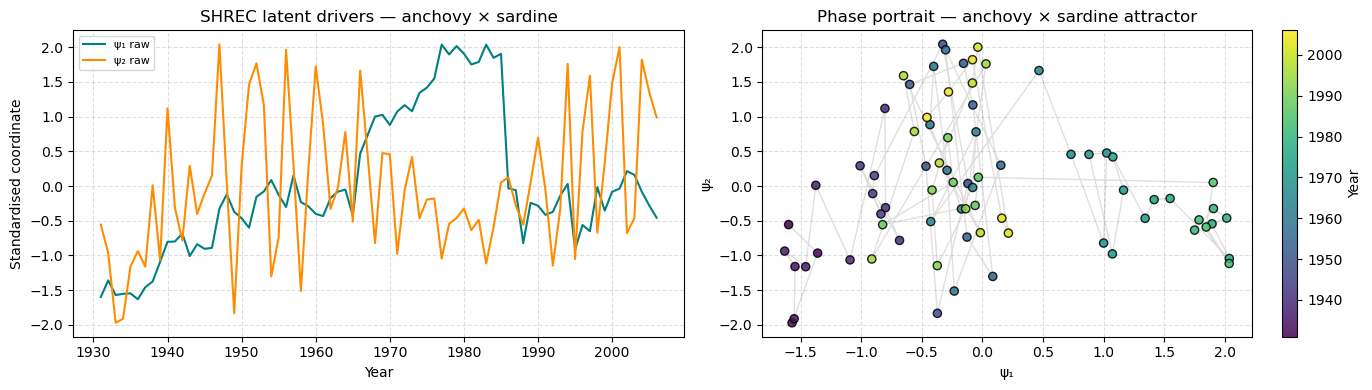

In [9]:
# ── SHREC building blocks ─────────────────────────────────────────────────────
def knn_affinity(ts, E=3, tau=1, k=10):
    """Gaussian k-NN affinity matrix on the time-delay embedded manifold."""
    n_embed = len(ts) - (E - 1) * tau
    M = np.array([[ts[i + (E-1)*tau - j*tau] for j in range(E)]
                  for i in range(n_embed)])
    D = cdist(M, M, metric='euclidean')
    A = np.zeros_like(D)
    for i in range(n_embed):
        nn = np.argsort(D[i])[1:k + 1]
        σ  = np.mean(D[i, nn]) + 1e-12
        A[i, nn] = np.exp(-D[i, nn]**2 / (2 * σ**2))
    return (A + A.T) / 2          # symmetrise

def shrec(ts_list, E=3, tau=1, k=10, n_components=2):
    """Spectral latent coordinates from the consensus affinity matrix."""
    A = np.sum([knn_affinity(ts, E, tau, k) for ts in ts_list], axis=0)
    d = A.sum(axis=1); d[d == 0] = 1e-12
    D_inv_sqrt = np.diag(1.0 / np.sqrt(d))
    L_sym = np.eye(len(A)) - D_inv_sqrt @ A @ D_inv_sqrt
    vals, vecs = eigh(L_sym)
    order = np.argsort(vals)
    return vecs[:, order][:, 1:1 + n_components]   # skip trivial λ=0

def zscore(v):
    return (v - v.mean()) / (v.std() + 1e-12)

# ──────────────────────────────────────────────────────────────────────────────
# RUN SHREC ON ANCHOVY × SARDINE
# E=3 matches what CCM will use; k=10 as before
# ──────────────────────────────────────────────────────────────────────────────
E_shrec = 3
k_shrec = 10

modes = shrec([anchovy, sardine], E=E_shrec, tau=1, k=k_shrec, n_components=2)

# Z-score for visual consistency
psi_1 = zscore(modes[:, 0])   # length = N - (E_shrec-1) = 76
psi_2 = zscore(modes[:, 1])

# Calendar axis for SHREC output
time_shrec = years[E_shrec - 1:]      # e.g. 1931–2006

print(f"SHREC(anchovy × sardine)  →  ψ₁, ψ₂  shape = {psi_1.shape}")
print(f"Calendar coverage: {time_shrec[0]}–{time_shrec[-1]}")

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

window = 5; hw = window // 2
sm1 = np.convolve(psi_1, np.ones(window)/window, mode='same')
sm2 = np.convolve(psi_2, np.ones(window)/window, mode='same')

axes[0].plot(time_shrec, psi_1, color='teal',   lw=1.5, label='ψ₁ raw')
axes[0].plot(time_shrec, psi_2, color='darkorange', lw=1.5, label='ψ₂ raw')
axes[0].set(xlabel='Year', ylabel='Standardised coordinate',
            title='SHREC latent drivers — anchovy × sardine')
axes[0].legend(fontsize=8); axes[0].grid(ls='--', alpha=0.4)

sc = axes[1].scatter(psi_1, psi_2, c=time_shrec, cmap='viridis',
                     s=35, edgecolor='k', alpha=0.85, zorder=3)
axes[1].plot(psi_1, psi_2, color='gray', alpha=0.25, lw=1, zorder=2)
axes[1].set(xlabel='ψ₁', ylabel='ψ₂',
            title='Phase portrait — anchovy × sardine attractor')
axes[1].grid(ls='--', alpha=0.4)
fig.colorbar(sc, ax=axes[1], label='Year')

plt.tight_layout()
plt.savefig("shrec_anchovy_sardine.png", dpi=150)
plt.show()


## 3 — SINDy Predictions & Residuals

SINDy discovered equations (z-scored variables):

| Variable | Equation |
|----------|----------|
| a(t+1)   | −0.44 a(t) + 0.60 sin(s(t)) |
| s(t+1)   | −0.50 − 0.49 a(t)·s(t) + 0.65 cos(s(t)) |

Residual = actual s(t+1) − SINDy predicted s(t+1).

**Alignment note:**  
- Raw series: length N = 78  
- SINDy residuals use indices `[1:]` of the raw series → length 77, covers years[1:]  
- SHREC ψ dropped the first `(E−1)=2` points → length 76, covers years[2:]  
- To align: we drop `residuals[0]` (year[1]) → both cover years[2:], length 76  


✅ All series aligned to years[2:]  (length = 76)
   Residual std = 0.9154   (sardine std = 0.9936)


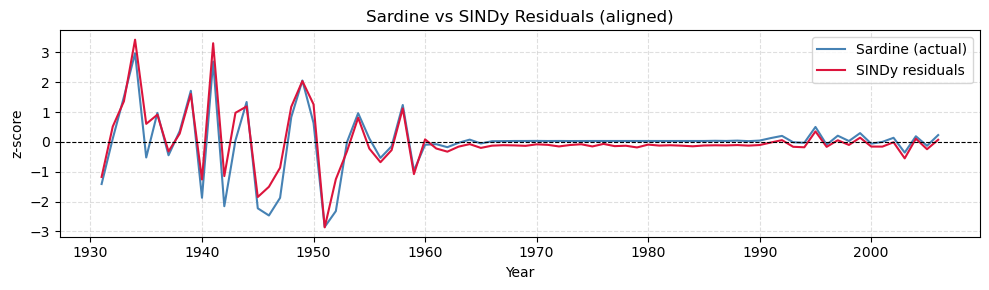

In [10]:
# ── Compute SINDy one-step predictions ───────────────────────────────────────
a_t = anchovy[:-1]   # t = 0 … N-2
s_t = sardine[:-1]

sardine_sindy_pred = -0.50 - 0.49 * a_t * s_t + 0.65 * np.cos(s_t)

# Full residual series (length N-1 = 77, covers years[1:])
sindy_residuals_full = sardine[1:] - sardine_sindy_pred

# ── Align to SHREC timeline ───────────────────────────────────────────────────
# SHREC covers years[E_shrec-1:]  →  years[2:]   (indices 2..77, length 76)
# Residuals cover years[1:]       →  years[1:]   (indices 1..77, length 77)
# Overlap starts at years[2:]  →  drop residuals[0]

shrec_start   = E_shrec - 1          # = 2
sindy_residuals = sindy_residuals_full[shrec_start - 1:]   # drop years[1], keep years[2:]
psi_1_aligned   = psi_1.copy()       # already covers years[2:], length 76
psi_2_aligned   = psi_2.copy()

assert len(sindy_residuals) == len(psi_1_aligned), (
    f"Length mismatch: residuals={len(sindy_residuals)}, ψ={len(psi_1_aligned)}")

# Also align the fish series to the same window (for Step 1)
sardine_aligned = sardine[shrec_start:]    # years[2:], length 76
anchovy_aligned = anchovy[shrec_start:]

print(f"✅ All series aligned to years[{shrec_start}:]  (length = {len(psi_1_aligned)})")
print(f"   Residual std = {sindy_residuals.std():.4f}   "
      f"(sardine std = {sardine.std():.4f})")

# Quick sanity plot
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(time_shrec, sardine_aligned,    color='steelblue', lw=1.5, label='Sardine (actual)')
ax.plot(time_shrec, sindy_residuals,    color='crimson',   lw=1.5, label='SINDy residuals')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set(xlabel='Year', ylabel='z-score', title='Sardine vs SINDy Residuals (aligned)')
ax.legend(); ax.grid(ls='--', alpha=0.4)
plt.tight_layout(); plt.show()


---
## Step 1 — CCM: ψ₁ and ψ₂ vs Fish Populations

Tests whether the anchovy×sardine latent driver (ψ₁, ψ₂) causally forces
the observed fish populations.  Both modes are tested so we can see whether
the second coordinate adds independent causal information.


Step 1  L_range: 10–72   (32 values)
Running 8 CCM directions …
Done.


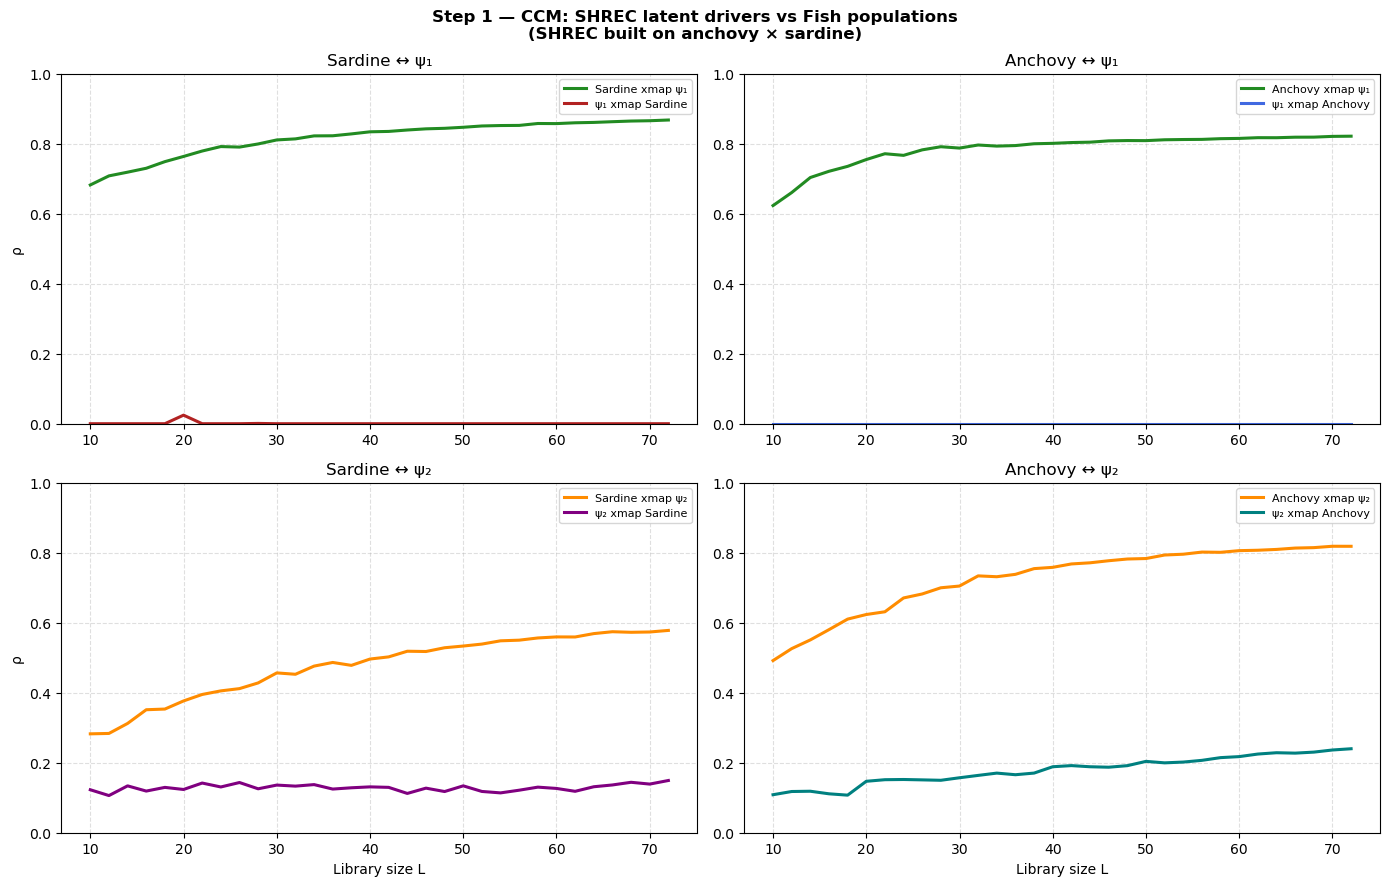

In [11]:
E_eco, tau_eco = 3, 1

def safe_L_range(series_list, E, tau, margin=1):
    """Largest usable library range given a list of series."""
    n_valid = min(
        int(np.sum(~np.isnan(embed(s, E, tau)).any(axis=1)))
        for s in series_list
    )
    return np.arange(10, n_valid - margin, 2)

L_range_step1 = safe_L_range(
    [psi_1_aligned, psi_2_aligned, sardine_aligned, anchovy_aligned],
    E_eco, tau_eco
)
print(f"Step 1  L_range: {L_range_step1[0]}–{L_range_step1[-1]}   "
      f"({len(L_range_step1)} values)")
print("Running 8 CCM directions …")

# ── ψ₁ ↔ fish ─────────────────────────────────────────────────────────────────
L1, rho_sard_x_psi1 = ccm_smooth(sardine_aligned, psi_1_aligned, E_eco, tau_eco, L_range_step1)
_,  rho_psi1_x_sard = ccm_smooth(psi_1_aligned, sardine_aligned, E_eco, tau_eco, L_range_step1)
_,  rho_anch_x_psi1 = ccm_smooth(anchovy_aligned, psi_1_aligned, E_eco, tau_eco, L_range_step1)
_,  rho_psi1_x_anch = ccm_smooth(psi_1_aligned, anchovy_aligned, E_eco, tau_eco, L_range_step1)

# ── ψ₂ ↔ fish ─────────────────────────────────────────────────────────────────
_,  rho_sard_x_psi2 = ccm_smooth(sardine_aligned, psi_2_aligned, E_eco, tau_eco, L_range_step1)
_,  rho_psi2_x_sard = ccm_smooth(psi_2_aligned, sardine_aligned, E_eco, tau_eco, L_range_step1)
_,  rho_anch_x_psi2 = ccm_smooth(anchovy_aligned, psi_2_aligned, E_eco, tau_eco, L_range_step1)
_,  rho_psi2_x_anch = ccm_smooth(psi_2_aligned, anchovy_aligned, E_eco, tau_eco, L_range_step1)

print("Done.")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Step 1 — CCM: SHREC latent drivers vs Fish populations\n'
             '(SHREC built on anchovy × sardine)', fontsize=12, fontweight='bold')

kw = dict(lw=2.2)
# Row 0: ψ₁
axes[0,0].plot(L1, rho_sard_x_psi1, color='forestgreen', **kw, label='Sardine xmap ψ₁')
axes[0,0].plot(L1, rho_psi1_x_sard, color='firebrick',   **kw, label='ψ₁ xmap Sardine')
axes[0,0].set(title='Sardine ↔ ψ₁', ylabel='ρ', ylim=(0,1))
axes[0,0].legend(fontsize=8); axes[0,0].grid(ls='--', alpha=0.4)

axes[0,1].plot(L1, rho_anch_x_psi1, color='forestgreen', **kw, label='Anchovy xmap ψ₁')
axes[0,1].plot(L1, rho_psi1_x_anch, color='royalblue',   **kw, label='ψ₁ xmap Anchovy')
axes[0,1].set(title='Anchovy ↔ ψ₁', ylim=(0,1))
axes[0,1].legend(fontsize=8); axes[0,1].grid(ls='--', alpha=0.4)

# Row 1: ψ₂
axes[1,0].plot(L1, rho_sard_x_psi2, color='darkorange',  **kw, label='Sardine xmap ψ₂')
axes[1,0].plot(L1, rho_psi2_x_sard, color='purple',      **kw, label='ψ₂ xmap Sardine')
axes[1,0].set(title='Sardine ↔ ψ₂', xlabel='Library size L', ylabel='ρ', ylim=(0,1))
axes[1,0].legend(fontsize=8); axes[1,0].grid(ls='--', alpha=0.4)

axes[1,1].plot(L1, rho_anch_x_psi2, color='darkorange',  **kw, label='Anchovy xmap ψ₂')
axes[1,1].plot(L1, rho_psi2_x_anch, color='teal',        **kw, label='ψ₂ xmap Anchovy')
axes[1,1].set(title='Anchovy ↔ ψ₂', xlabel='Library size L', ylim=(0,1))
axes[1,1].legend(fontsize=8); axes[1,1].grid(ls='--', alpha=0.4)

plt.tight_layout()
plt.savefig("step1_ccm_psi_vs_fish.png", dpi=150)
plt.show()


---
## Step 2 — CCM: ψ₁ and ψ₂ vs SINDy Residuals

Tests whether the hidden driver encoded in ψ explains the variance that SINDy
could not capture.  Both ψ₁ and ψ₂ are evaluated to check which mode (if any)
contains the missing dynamics.


Step 2  L_range: 10–72   (32 values)
Running 4 CCM directions …
Done.


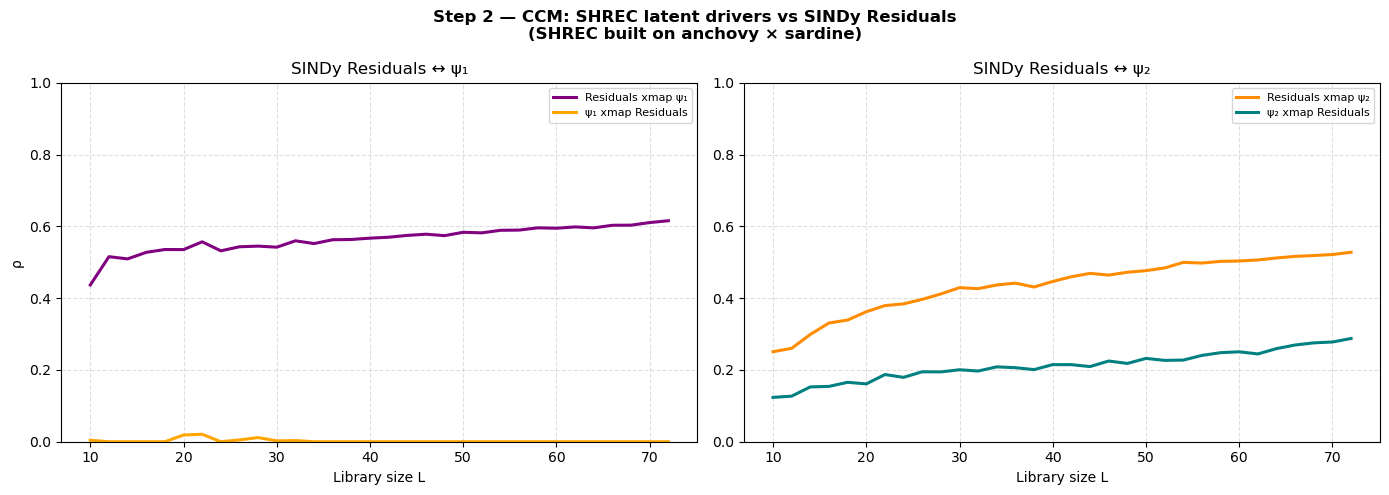

In [6]:
L_range_step2 = safe_L_range(
    [psi_1_aligned, psi_2_aligned, sindy_residuals],
    E_eco, tau_eco
)
print(f"Step 2  L_range: {L_range_step2[0]}–{L_range_step2[-1]}   "
      f"({len(L_range_step2)} values)")
print("Running 4 CCM directions …")

# ── ψ₁ ↔ residuals ────────────────────────────────────────────────────────────
L2, rho_res_x_psi1  = ccm_smooth(sindy_residuals, psi_1_aligned, E_eco, tau_eco, L_range_step2)
_,  rho_psi1_x_res  = ccm_smooth(psi_1_aligned, sindy_residuals, E_eco, tau_eco, L_range_step2)

# ── ψ₂ ↔ residuals ────────────────────────────────────────────────────────────
_,  rho_res_x_psi2  = ccm_smooth(sindy_residuals, psi_2_aligned, E_eco, tau_eco, L_range_step2)
_,  rho_psi2_x_res  = ccm_smooth(psi_2_aligned, sindy_residuals, E_eco, tau_eco, L_range_step2)

print("Done.")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Step 2 — CCM: SHREC latent drivers vs SINDy Residuals\n'
             '(SHREC built on anchovy × sardine)', fontsize=12, fontweight='bold')

axes[0].plot(L2, rho_res_x_psi1,  color='purple', lw=2.2, label='Residuals xmap ψ₁')
axes[0].plot(L2, rho_psi1_x_res,  color='orange', lw=2.2, label='ψ₁ xmap Residuals')
axes[0].set(title='SINDy Residuals ↔ ψ₁',
            xlabel='Library size L', ylabel='ρ', ylim=(0,1))
axes[0].legend(fontsize=8); axes[0].grid(ls='--', alpha=0.4)

axes[1].plot(L2, rho_res_x_psi2,  color='darkorange', lw=2.2, label='Residuals xmap ψ₂')
axes[1].plot(L2, rho_psi2_x_res,  color='teal',       lw=2.2, label='ψ₂ xmap Residuals')
axes[1].set(title='SINDy Residuals ↔ ψ₂',
            xlabel='Library size L', ylim=(0,1))
axes[1].legend(fontsize=8); axes[1].grid(ls='--', alpha=0.4)

plt.tight_layout()
plt.savefig("step2_ccm_psi_vs_residuals.png", dpi=150)
plt.show()


---
## Step 3 — Convergence Analysis

Exponential convergence fits for all CCM curves from Steps 1 and 2.
ρ∞ > 0 with finite γ = genuine causal signal.


STEP 3 — CONVERGENCE ANALYSIS (all CCM curves)

ψ₁ curves:
  Sardine xmap ψ₁                                         | ✅  ρ∞ = 0.870   (γ = 0.0543)
  ψ₁ xmap Sardine                                         | ✅  ρ∞ = 0.001   (γ = 0.5546)
  Anchovy xmap ψ₁                                         | ✅  ρ∞ = 0.814   (γ = 0.1082)
  ψ₁ xmap Anchovy                                         | ➡  flat / no convergence
  Residuals xmap ψ₁                                       | ✅  ρ∞ = 0.619   (γ = 0.0345)
  ψ₁ xmap Residuals                                       | ✅  ρ∞ = 0.000   (γ = 0.0373)

ψ₂ curves:
  Sardine xmap ψ₂                                         | ✅  ρ∞ = 0.621   (γ = 0.0345)
  ψ₂ xmap Sardine                                         | ✅  ρ∞ = 0.130   (γ = 0.2277)
  Anchovy xmap ψ₂                                         | ✅  ρ∞ = 0.833   (γ = 0.0510)
  ψ₂ xmap Anchovy                                         | ✅  ρ∞ = 0.401   (γ = 0.0095)
  Residuals xmap ψ₂                        

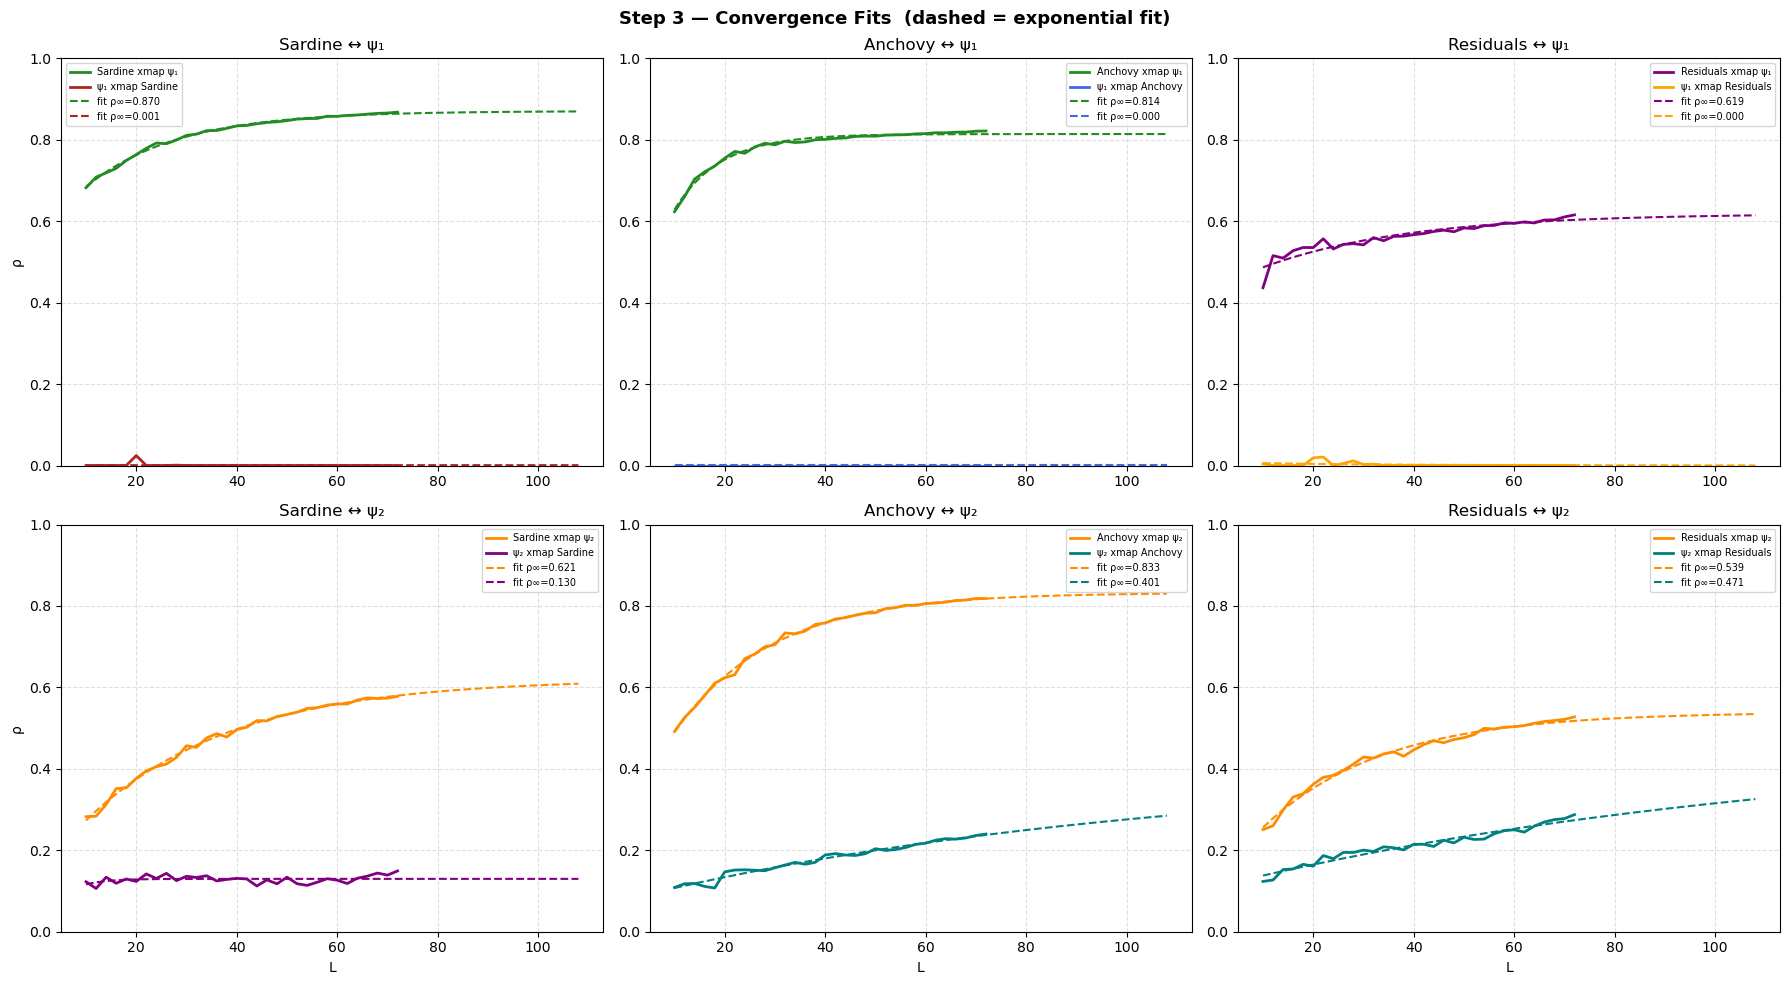


Interpretation:
  ρ∞ > 0.3 and rising with L  →  genuine causal signal
  flat / near-zero             →  no detectable causation


In [7]:
print("=" * 72)
print("STEP 3 — CONVERGENCE ANALYSIS (all CCM curves)")
print("=" * 72)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Step 3 — Convergence Fits  (dashed = exponential fit)',
             fontsize=13, fontweight='bold')

# ──────────────────── Row 0: ψ₁ ──────────────────────────────────────────────
print("\nψ₁ curves:")

ax = axes[0, 0]
ax.plot(L1, rho_sard_x_psi1, color='forestgreen', lw=2, label='Sardine xmap ψ₁')
ax.plot(L1, rho_psi1_x_sard, color='firebrick',   lw=2, label='ψ₁ xmap Sardine')
fit_convergence(L1, rho_sard_x_psi1, "Sardine xmap ψ₁", ax, 'forestgreen')
fit_convergence(L1, rho_psi1_x_sard, "ψ₁ xmap Sardine", ax, 'firebrick')
ax.set(title='Sardine ↔ ψ₁', ylabel='ρ', ylim=(0,1))
ax.legend(fontsize=7); ax.grid(ls='--', alpha=0.4)

ax = axes[0, 1]
ax.plot(L1, rho_anch_x_psi1, color='forestgreen', lw=2, label='Anchovy xmap ψ₁')
ax.plot(L1, rho_psi1_x_anch, color='royalblue',   lw=2, label='ψ₁ xmap Anchovy')
fit_convergence(L1, rho_anch_x_psi1, "Anchovy xmap ψ₁", ax, 'forestgreen')
fit_convergence(L1, rho_psi1_x_anch, "ψ₁ xmap Anchovy", ax, 'royalblue')
ax.set(title='Anchovy ↔ ψ₁', ylim=(0,1))
ax.legend(fontsize=7); ax.grid(ls='--', alpha=0.4)

ax = axes[0, 2]
ax.plot(L2, rho_res_x_psi1,  color='purple', lw=2, label='Residuals xmap ψ₁')
ax.plot(L2, rho_psi1_x_res,  color='orange', lw=2, label='ψ₁ xmap Residuals')
fit_convergence(L2, rho_res_x_psi1,  "Residuals xmap ψ₁",  ax, 'purple')
fit_convergence(L2, rho_psi1_x_res,  "ψ₁ xmap Residuals",  ax, 'orange')
ax.set(title='Residuals ↔ ψ₁', ylim=(0,1))
ax.legend(fontsize=7); ax.grid(ls='--', alpha=0.4)

# ──────────────────── Row 1: ψ₂ ──────────────────────────────────────────────
print("\nψ₂ curves:")

ax = axes[1, 0]
ax.plot(L1, rho_sard_x_psi2, color='darkorange', lw=2, label='Sardine xmap ψ₂')
ax.plot(L1, rho_psi2_x_sard, color='purple',     lw=2, label='ψ₂ xmap Sardine')
fit_convergence(L1, rho_sard_x_psi2, "Sardine xmap ψ₂", ax, 'darkorange')
fit_convergence(L1, rho_psi2_x_sard, "ψ₂ xmap Sardine", ax, 'purple')
ax.set(title='Sardine ↔ ψ₂', xlabel='L', ylabel='ρ', ylim=(0,1))
ax.legend(fontsize=7); ax.grid(ls='--', alpha=0.4)

ax = axes[1, 1]
ax.plot(L1, rho_anch_x_psi2, color='darkorange', lw=2, label='Anchovy xmap ψ₂')
ax.plot(L1, rho_psi2_x_anch, color='teal',       lw=2, label='ψ₂ xmap Anchovy')
fit_convergence(L1, rho_anch_x_psi2, "Anchovy xmap ψ₂", ax, 'darkorange')
fit_convergence(L1, rho_psi2_x_anch, "ψ₂ xmap Anchovy", ax, 'teal')
ax.set(title='Anchovy ↔ ψ₂', xlabel='L', ylim=(0,1))
ax.legend(fontsize=7); ax.grid(ls='--', alpha=0.4)

ax = axes[1, 2]
ax.plot(L2, rho_res_x_psi2,  color='darkorange', lw=2, label='Residuals xmap ψ₂')
ax.plot(L2, rho_psi2_x_res,  color='teal',       lw=2, label='ψ₂ xmap Residuals')
fit_convergence(L2, rho_res_x_psi2,  "Residuals xmap ψ₂",  ax, 'darkorange')
fit_convergence(L2, rho_psi2_x_res,  "ψ₂ xmap Residuals",  ax, 'teal')
ax.set(title='Residuals ↔ ψ₂', xlabel='L', ylim=(0,1))
ax.legend(fontsize=7); ax.grid(ls='--', alpha=0.4)

plt.tight_layout()
plt.savefig("step3_convergence_all.png", dpi=150)
plt.show()

print()
print("Interpretation:")
print("  ρ∞ > 0.3 and rising with L  →  genuine causal signal")
print("  flat / near-zero             →  no detectable causation")
